# Introduction

**AIM:**

The aim of this notebook is to explore the dataset for predictive maintenance of a electrical machine. It has vibrational and rotational motion and operate at certain level of humidity.

**Purpose:** 

The electrical machines needs regular maintenance and it is always better for owner to have proper servicing of machine. It is better for machine performance and the owner from business point of view to have preemptive emasures to service the machine rather than repairing it after breakage incident. To achive this purpose the dataset is employed for EDA.

**Objective:**

The above mentioned purpose can be achived by employing proper datascience pipeline, where machine learning models will be used to predict the failure points.

# Calling the python libraries:

In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Calling the dataset for EDA:

In [145]:
# calling the raw dataset df
# call home directory

df = pd.read_csv("/home/ram-gurung/Documents/projects/predictive_maintenance_edge/predictive_maintenance_edge/data/raw/predictive-maintenance-dataset.csv"
, low_memory=False) # to keep the memory usage low while importing the file.



# EDA

In [146]:
df

,ID,revolutions,humidity,vibration,x1,x2,x3,x4,x5
0,1,93.744,73.999,18.00,167.743,19.745,1.266828,8787.937536,5475.852001
1,2,93.740,73.999,18.00,167.739,19.741,1.266774,8787.187600,5475.852001
2,3,93.736,73.998,18.00,167.734,19.738,1.266737,8786.437696,5475.704004
3,4,93.732,73.998,18.00,167.730,19.734,1.266683,8785.687824,5475.704004
4,5,93.729,73.998,18.00,167.727,19.731,1.266642,8785.125441,5475.704004
...,...,...,...,...,...,...,...,...,...
111996,111997,20.186,73.992,2.00,94.178,-53.806,0.272813,407.474596,5474.816064
111997,111998,20.186,73.992,20.01,94.178,-53.806,0.272813,407.474596,5474.816064
111998,111999,20.185,73.992,20.01,94.177,-53.807,0.272800,407.434225,5474.816064
111999,112000,20.185,73.992,20.00,94.177,-53.807,0.272800,407.434225,5474.816064


In [147]:
# to get the initial representation

print(df.head(5))

print("===============================")
print(df.dtypes)

print("================================")
print(df.shape)


   ID  revolutions  humidity  vibration       x1      x2        x3  \
0   1       93.744    73.999       18.0  167.743  19.745  1.266828   
1   2       93.740    73.999       18.0  167.739  19.741  1.266774   
2   3       93.736    73.998       18.0  167.734  19.738  1.266737   
3   4       93.732    73.998       18.0  167.730  19.734  1.266683   
4   5       93.729    73.998       18.0  167.727  19.731  1.266642   

            x4           x5  
0  8787.937536  5475.852001  
1  8787.187600  5475.852001  
2  8786.437696  5475.704004  
3  8785.687824  5475.704004  
4  8785.125441  5475.704004  
ID               int64
revolutions    float64
humidity       float64
vibration      float64
x1             float64
x2             float64
x3             float64
x4             float64
x5             float64
dtype: object
(112001, 9)


In [148]:
# to see from where the csv is running

print(os.getcwd())

/home/ram-gurung/Documents/projects/predictive_maintenance_edge/predictive_maintenance_edge/notebooks


In [149]:
# to get summary statistics

print(df.describe())

# note: the less values in vibration indicates the presence of null values in vibrational data. 

                  ID    revolutions       humidity      vibration  \
count  112001.000000  112001.000000  112001.000000  109563.000000   
mean    56001.000000      46.275195      74.224140      28.340276   
std     32332.048087      19.042179       0.684711      24.292500   
min         1.000000      16.933000      72.399000       2.000000   
25%     28001.000000      29.651000      73.914000       8.000000   
50%     56001.000000      43.348000      74.212000      21.280000   
75%     84001.000000      63.997000      74.731000      39.210000   
max    112001.000000      93.744000      75.400000     100.000000   

                  x1             x2             x3             x4  \
count  112001.000000  112001.000000  112001.000000  112001.000000   
mean      120.499335     -27.948945       0.623759    2503.994994   
std        18.984921      19.123796       0.258677    1874.972912   
min        90.132000     -56.353000       0.231328     286.726489   
25%       103.850000     -44.5480

In [150]:
# to look for null values 
# as the counted values in vibration column is less than total values we can say it has null values to check it :

df.isnull().sum()  #.sum() function will give total null values

ID                0
revolutions       0
humidity          0
vibration      2438
x1                0
x2                0
x3                0
x4                0
x5                0
dtype: int64

In [151]:
# checking the percentage of null value raws in csv

x = (2438/112001)*100
print(x)

2.1767662788725097


In [152]:
"""
# it is plausible to delete the null value raws but instead filling it with average values to maintain data integrity.

df['vibration'] = df['vibration'].fillna(df['vibration'].mean())

"""

"\n# it is plausible to delete the null value raws but instead filling it with average values to maintain data integrity.\n\ndf['vibration'] = df['vibration'].fillna(df['vibration'].mean())\n\n"

In [153]:
# checking whether it worked or not?

df.isnull().sum()

ID                0
revolutions       0
humidity          0
vibration      2438
x1                0
x2                0
x3                0
x4                0
x5                0
dtype: int64

# Some generic questions

**Some generic questions**

 How are the rows of the dataset uniquely identified? (What is the unit of analysis?) or check duplicates.
 
• How many rows and columns are in the dataset?

• What are the key categorical variables and the frequencies of each value?

• How are important continuous variables distributed?

• How might variables be related to each other – for example, how might the 

distribution of continuous variables vary according to categories in the data?

• What variable values are out of expected ranges, and how are missing values 
distributed?

# How are the rows of the dataset uniquely identified? (What is the unit of analysis?) duplicate checking.

In [154]:
# How are the rows of the dataset uniquely identified? (What is the unit of analysis?)

# to see this 

print(df.columns)

# to see whether the id clumn is unique or not

print(df['ID'].nunique())

# comparing it to total rows
print(len(df))

# to check duplicate rows
df.duplicated().sum()

Index(['ID', 'revolutions', 'humidity', 'vibration', 'x1', 'x2', 'x3', 'x4',
       'x5'],
      dtype='str')
112001
112001


np.int64(0)

In [155]:
# to get the identifier of columns 
# if a column has same number of unique values as rows, it may be identifier.

for col in df.columns:
    print(col, df[col].nunique(), "/", len(df))

ID 112001 / 112001
revolutions 47837 / 112001
humidity 3002 / 112001
vibration 9020 / 112001
x1 48740 / 112001
x2 46246 / 112001
x3 85419 / 112001
x4 47837 / 112001
x5 3002 / 112001


# How many rows and columns are in the dataset?

In [156]:
# to get the details separately

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 112001
Columns: 9


In [157]:
# to see column names
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 112001 entries, 0 to 112000
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   ID           112001 non-null  int64  
 1   revolutions  112001 non-null  float64
 2   humidity     112001 non-null  float64
 3   vibration    109563 non-null  float64
 4   x1           112001 non-null  float64
 5   x2           112001 non-null  float64
 6   x3           112001 non-null  float64
 7   x4           112001 non-null  float64
 8   x5           112001 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 7.7 MB
None


# What are the key categorical variables and frequencies of each value?

In [158]:
# to check whether there are some categorical columns are p[resent or not ?

df.select_dtypes(include=["object", "category", "bool"]).columns

# output shows no categorical values

Index([], dtype='str')

# How are important continuous variables distributed?

In [159]:
def describe_with_mode(df):
    # Get the standard describe output
    desc = df.describe(percentiles=[.25, .5, .75])
    
    # Add mode as a new row (taking the first mode if multiple exist)
    desc.loc['mode'] = df.apply(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
    
    return desc

# Usage
print(describe_with_mode(df))


                  ID    revolutions       humidity      vibration  \
count  112001.000000  112001.000000  112001.000000  109563.000000   
mean    56001.000000      46.275195      74.224140      28.340276   
std     32332.048087      19.042179       0.684711      24.292500   
min         1.000000      16.933000      72.399000       2.000000   
25%     28001.000000      29.651000      73.914000       8.000000   
50%     56001.000000      43.348000      74.212000      21.280000   
75%     84001.000000      63.997000      74.731000      39.210000   
max    112001.000000      93.744000      75.400000     100.000000   
mode        1.000000      21.000000      74.023000       8.000000   

                  x1             x2             x3             x4  \
count  112001.000000  112001.000000  112001.000000  112001.000000   
mean      120.499335     -27.948945       0.623759    2503.994994   
std        18.984921      19.123796       0.258677    1874.972912   
min        90.132000     -56.3530

In [160]:
# to observe the skewness in the data 

print(df[["revolutions", "humidity", "vibration"]].skew())

revolutions    0.220401
humidity      -0.534430
vibration      0.986828
dtype: float64


# to see the distribution of values 

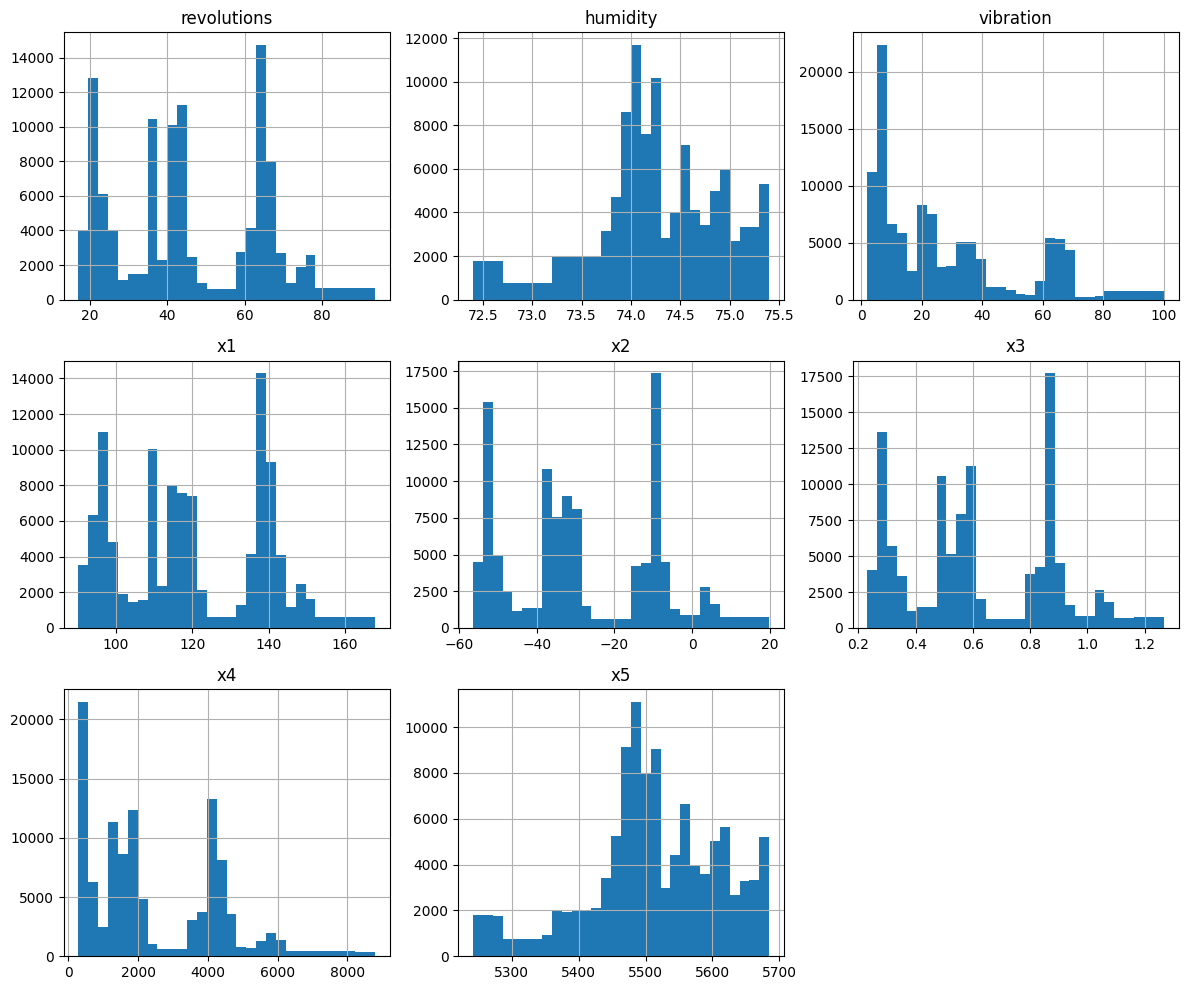

In [161]:
# Selecting only numeric columns
numeric_df = df.select_dtypes(include=['float64'])

# Plot histograms

%matplotlib inline
numeric_df.hist(bins=30, figsize=(12, 10))
plt.tight_layout()
plt.show()

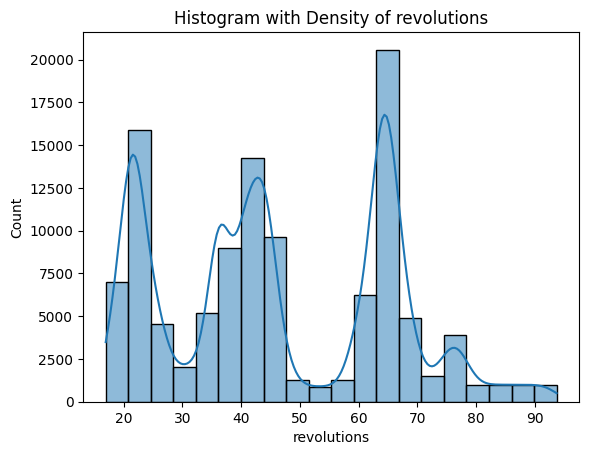

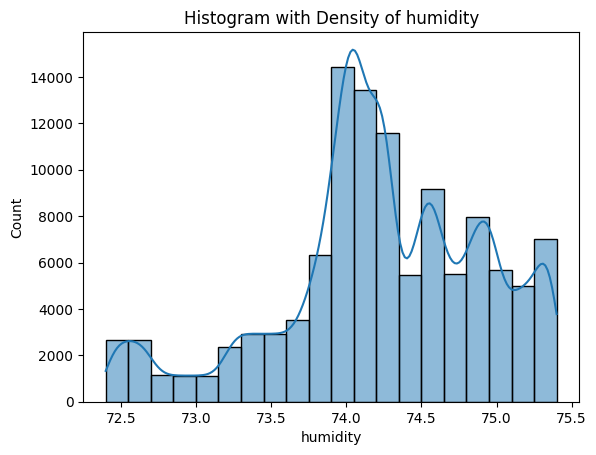

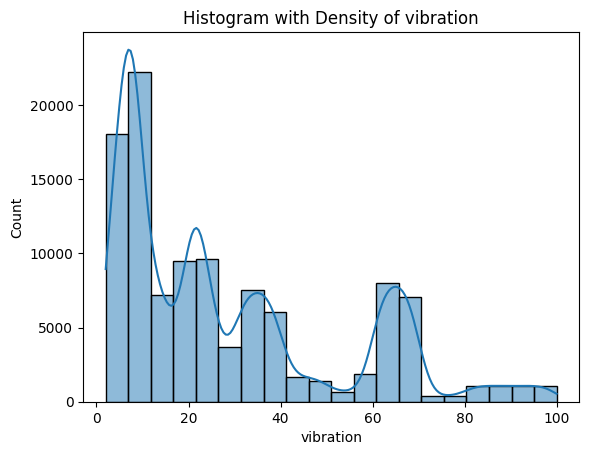

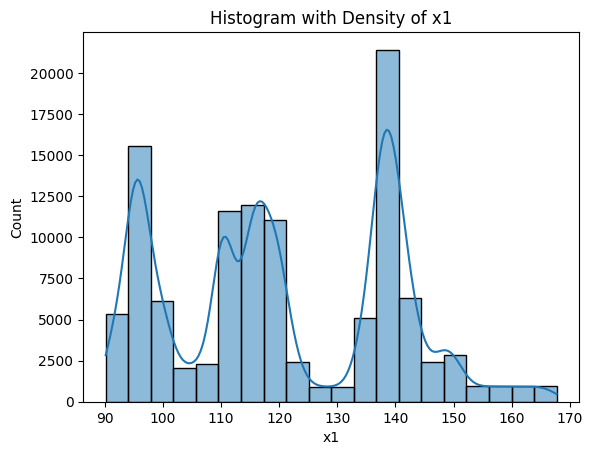

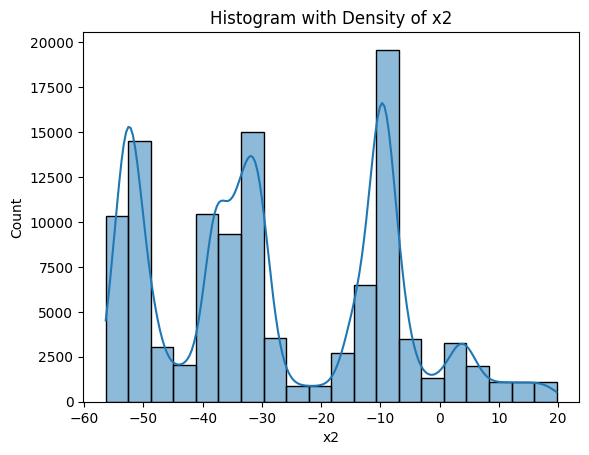

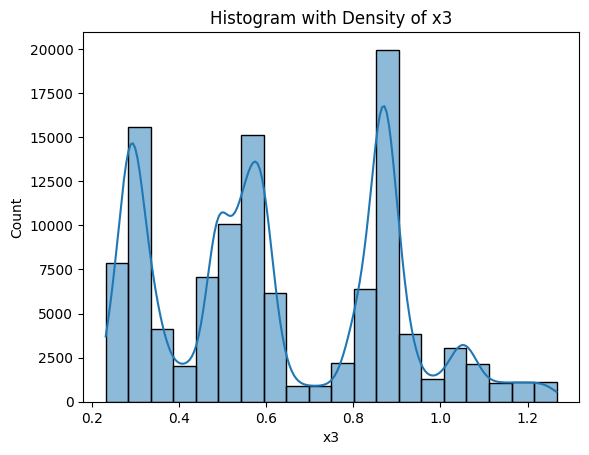

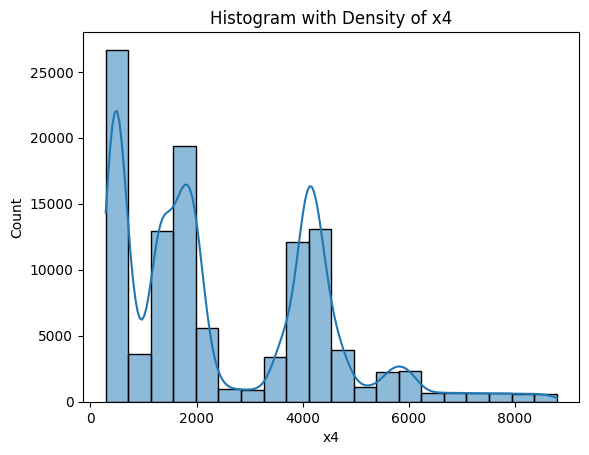

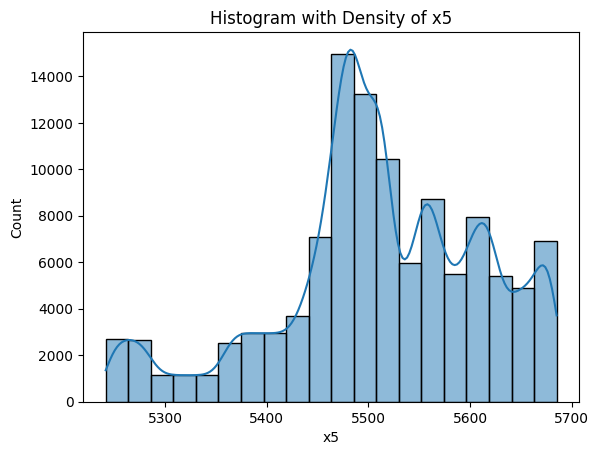

In [162]:
# with density plot overlay
%matplotlib inline
import seaborn as sns

for column in df.select_dtypes(include=['float64']).columns:
    plt.figure()
    sns.histplot(df[column], kde=True, bins=20)
    plt.title(f'Histogram with Density of {column}')
    plt.show()

# to find How might variables be related to each other?

In [163]:
# continuous vs continuous

# correlation matrix:

numeric_cols = df.select_dtypes(include="float64").columns
numeric_cols

Index(['revolutions', 'humidity', 'vibration', 'x1', 'x2', 'x3', 'x4', 'x5'], dtype='str')

In [164]:
# to get a correlation matrix
df[numeric_cols].corr()

,revolutions,humidity,vibration,x1,x2,x3,x4,x5
revolutions,1.000000,-0.101476,-0.114768,0.999356,0.999365,0.999593,0.982563,-0.098903
humidity,-0.101476,1.000000,0.136469,-0.065716,-0.136847,-0.128683,-0.207702,0.999980
vibration,-0.114768,0.136469,1.000000,-0.110225,-0.119131,-0.117370,-0.142570,0.136830
x1,0.999356,-0.065716,-0.110225,1.000000,0.997444,0.997967,0.978035,-0.063136
x2,0.999365,-0.136847,-0.119131,0.997444,1.000000,0.999934,0.985806,-0.134285
x3,0.999593,-0.128683,-0.117370,0.997967,0.999934,1.000000,0.985077,-0.126093
x4,0.982563,-0.207702,-0.142570,0.978035,0.985806,0.985077,1.000000,-0.205227
x5,-0.098903,0.999980,0.136830,-0.063136,-0.134285,-0.126093,-0.205227,1.000000


In [165]:
# to get Correlation with humidity variable:

df[numeric_cols].corr()["humidity"].sort_values(ascending=False)

humidity       1.000000
x5             0.999980
vibration      0.136469
x1            -0.065716
revolutions   -0.101476
x3            -0.128683
x2            -0.136847
x4            -0.207702
Name: humidity, dtype: float64

<Axes: xlabel='revolutions', ylabel='humidity'>

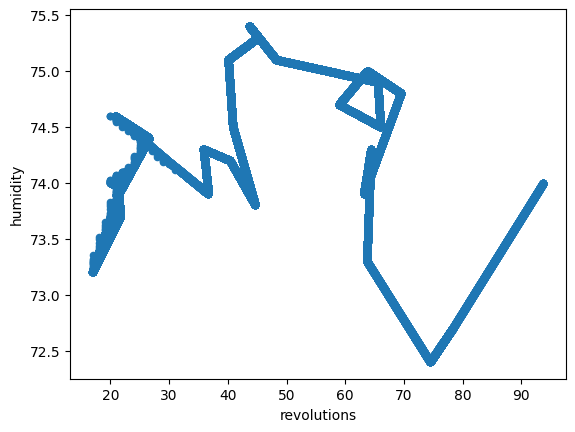

In [166]:
# scatter plot
df.plot.scatter(
    y="humidity",
    x="revolutions"
)

<Axes: xlabel='revolutions', ylabel='vibration'>

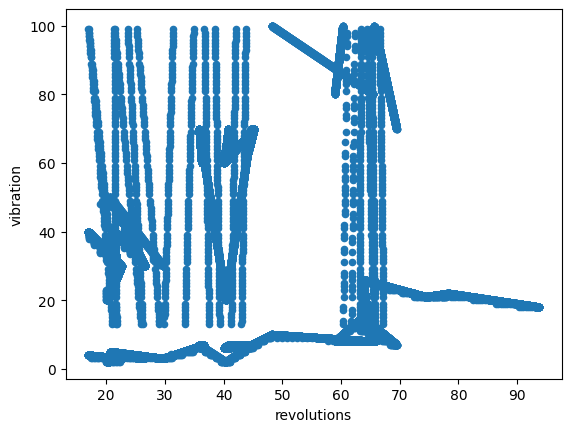

In [167]:
# scatter plot
df.plot.scatter(
    y="vibration",
    x="revolutions"
)

# What variable values are outside expected ranges?

In [168]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
revolutions,112001.0,46.275195,19.042179,16.933000,29.651000,43.348000,63.997000,93.744000
humidity,112001.0,74.224140,0.684711,72.399000,73.914000,74.212000,74.731000,75.400000
vibration,109563.0,28.340276,24.292500,2.000000,8.000000,21.280000,39.210000,100.000000
x1,112001.0,120.499335,18.984921,90.132000,103.850000,117.640000,138.119000,167.743000
x2,112001.0,-27.948945,19.123796,-56.353000,-44.548000,-31.443000,-10.012000,19.745000
x3,112001.0,0.623759,0.258677,0.231328,0.399615,0.580561,0.865330,1.266828
x4,112001.0,2503.994994,1874.972912,286.726489,879.181801,1879.049104,4095.616009,8787.937536
x5,112001.0,5509.691804,101.395621,5241.615201,5463.279396,5507.420944,5584.722361,5685.160000


In [169]:
# to find every potential numeric column outlier

numeric_cols = df.select_dtypes(include="float64").columns
numeric_cols

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = (
        (df[col] < lower) |
        (df[col] > upper)
    ).sum()

    print(col, ":", count, "outliers")

revolutions : 0 outliers
humidity : 5134 outliers
vibration : 3040 outliers
x1 : 0 outliers
x2 : 0 outliers
x3 : 0 outliers
x4 : 0 outliers
x5 : 4835 outliers


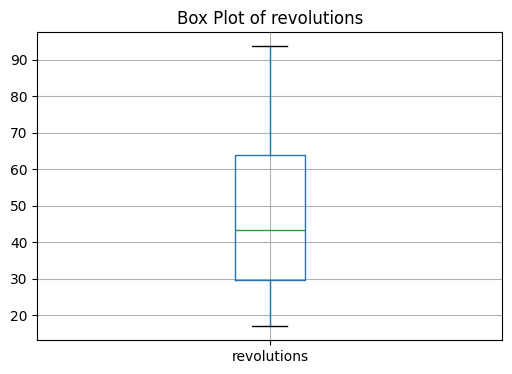

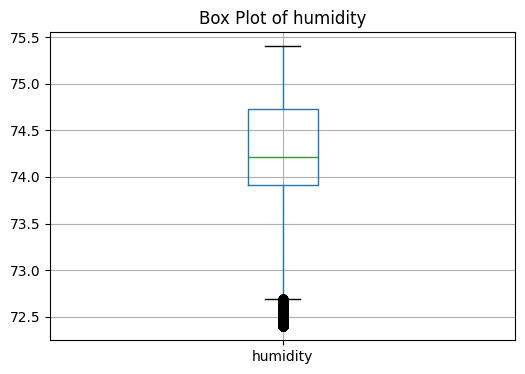

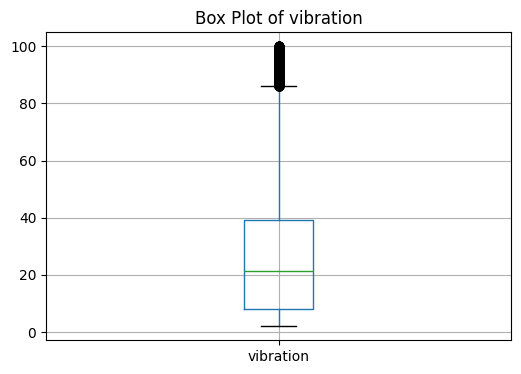

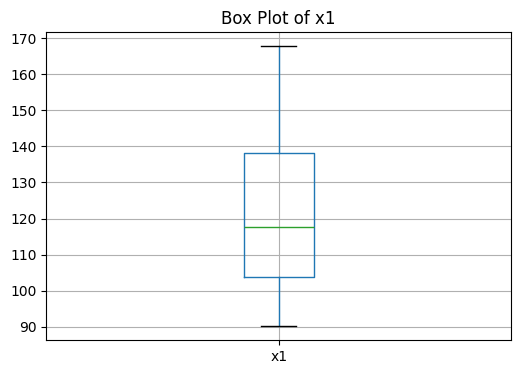

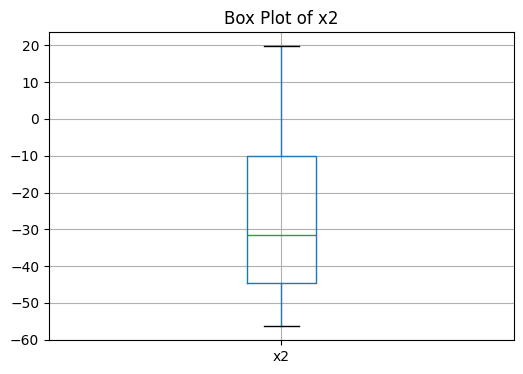

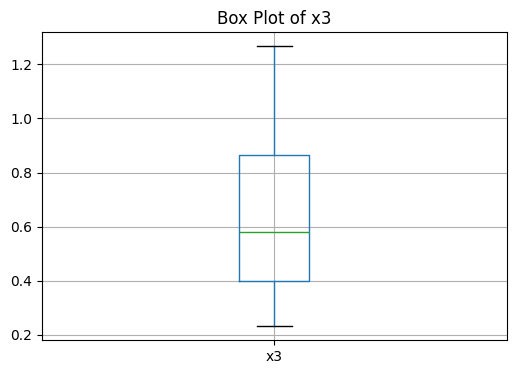

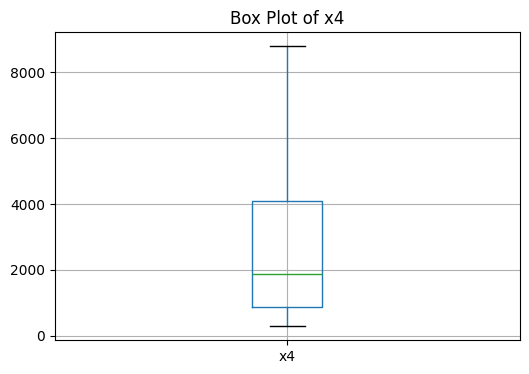

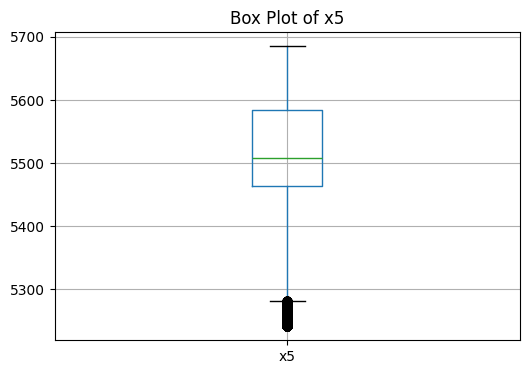

In [170]:
# for getting boxplot of columns with datatype float64

import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include="float64").columns

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    df.boxplot(column=col)
    plt.title(f"Box Plot of {col}")
    plt.show()

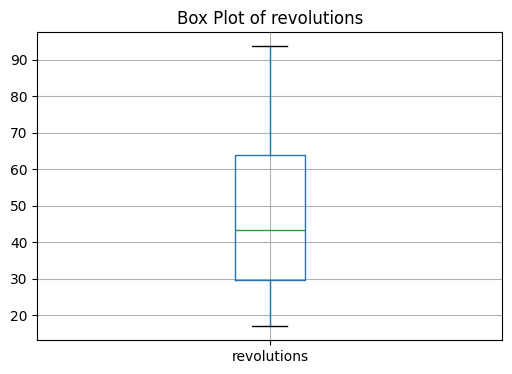

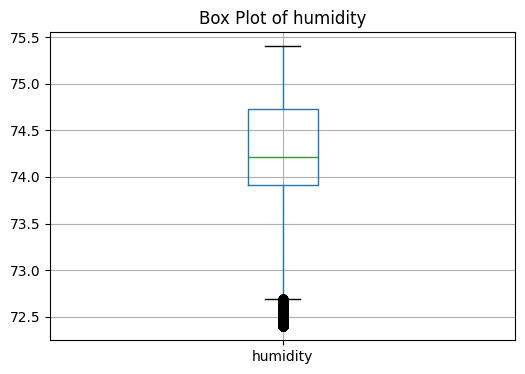

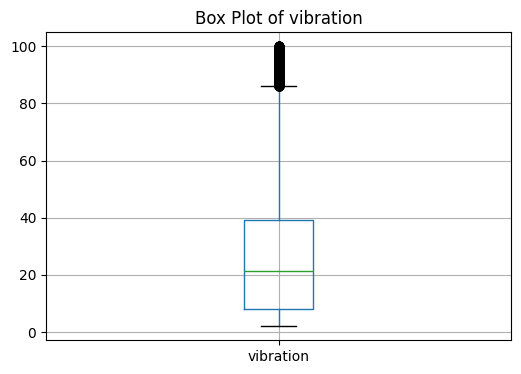

In [171]:
# for getting boxplot of desirable columns only

columns = [
    "revolutions",
    "humidity",
    "vibration",
    ]

for col in columns:
    plt.figure(figsize=(6, 4))
    df.boxplot(column=col)
    plt.title(f"Box Plot of {col}")
    plt.show()